# Pedigree consistency and other basic properties of tandem repeats in the CEPH pedigree

In [1]:
import os
import gzip
import itertools
import pathlib
from collections import namedtuple
import importlib

import numpy as np
from pandas import DataFrame
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline
plt.rcParams['figure.figsize'] = [16.5, 5]
plt.rcParams['font.size'] = 12

import helpers.consistency as cons
import helpers.allele_db as db

importlib.reload(cons)
importlib.reload(db)

<module 'helpers.allele_db' from '/pbi/flash/edolzhenko/2024/Q2/PlatinumPedigree/pipelines/tandem-repeats/helpers/allele_db.py'>

In [2]:
# Install the editdistance library
# python -m pip install editdistance

In [3]:
inheritance_vector_path = "/home/edolzhenko/flash/2024/Q2/palladium/000_ivecs.grch38.csv"

Load the inheritance vectors containing the expected inheritance patterns across (most of) the genome. 

In [4]:
ivecs = cons.load_ivecs(inheritance_vector_path)

In [5]:
def compress_homs(seq, min_len=4):
    comp_seq = ""
    for base, group in itertools.groupby(seq):
        run_len = len(list(group))
        comp_seq += base * min(min_len, run_len)
    return comp_seq


compress_homs("AAATTTTTTTTAATCGGTTTTTTT")

'AAATTTTAATCGGTTTT'

In [6]:
def compress_seqs(seqs):
    return tuple(compress_homs(s) for s in seqs)

In [9]:
Tr = namedtuple("Tr", "alleles purities")
Summary = namedtuple("Summary", "trid A B C D is_consistent mean_purity mean_len mean_gc distinct_alleles")


def summarize(hap_to_dists):
    num_imperfect = 0
    max_error = 0
    total_dist = 0
    for hap, dists in hap_to_dists.items():
        if not dists:
            continue
        if max(dists) != 0:
            num_imperfect += 1
        allele_error = (len(dists) - dists.count(0)) / len(dists)
        max_error = max(max_error, allele_error)
        total_dist += sum(dists)

    return num_imperfect, max_error, total_dist


def get_alleles(path, homopolymer_compression=False):
    with gzip.open(path, "r") as file:
        for trid, recs in itertools.groupby(file, key=lambda rec: rec.decode("utf8").split()[0]):
            if not trid.startswith("chr"):
                print(f"Skipping {trid}")
                continue
            recs = [rec.decode("utf8").split() for rec in recs]
            tr_by_sample = {}
            for trid, sample, alleles, purities in recs:
                alleles = tuple(alleles.split(","))
                purities = tuple(float(p) if p != "." else 0 for p in purities.split(","))
                if homopolymer_compression:
                    alleles = compress_seqs(alleles)
                tr = Tr(alleles, purities)
                tr_by_sample[sample] = tr
            yield trid, tr_by_sample


def get_ivec(inheritance_vecs, trid):
    chrom, start, end = trid.split("_")[:3]
    start, end = int(start), int(end)
    for inheritance_vec in inheritance_vecs:
        if inheritance_vec["chrom"] == chrom and inheritance_vec["start"] <= start and end <= inheritance_vec["end"]:
            return inheritance_vec
    return None


def get_score(hap_to_dists):
    score = 0
    for dists in hap_to_dists.values():
        score += sum(dists)
    return score


num_skipped = 0
tr_summaries = []
allele_iter = get_alleles("output/allele_db.gz", homopolymer_compression=False)
for num_total, (trid, tr_by_sample) in enumerate(allele_iter):
    # Skip loci missing alleles
    if len(tr_by_sample) != 10:
        num_skipped += 1
        continue

    ivec = get_ivec(ivecs, trid)
    # Also skip loci not covered by inheritance vectors
    if ivec is None:
        num_skipped += 1
        continue

    candidates = cons.get_candidates(ivec, tr_by_sample)
    assign, hap_to_dists = cons.get_best_assign(ivec, tr_by_sample, candidates)

    purities = []
    alleles = []
    for sample, tr in tr_by_sample.items():
        purities.extend(tr.purities)
        alleles.extend(tr.alleles)
    mean_purity = np.mean(purities)
    mean_len = np.mean([len(a) for a in alleles])
    mean_gc = np.mean([(a.count("G") + a.count("C")) / len(a) for a in alleles])
    distinct_alleles = len(set(alleles))

    num_imperfect, max_error, total_dist = summarize(hap_to_dists)
    is_consistent = num_imperfect == 0

    summary = Summary(trid, assign.A, assign.B, assign.C, assign.D,
                      is_consistent, mean_purity, mean_len, mean_gc,
                      distinct_alleles)
    tr_summaries.append(summary)

In [12]:
num_perfect = sum(summary.is_consistent for summary in tr_summaries)
print(f"Fraction skipped = {100 * num_skipped / num_total:.2f}%")
print(f"Fraction perfect = {100 * num_perfect / num_total:.2f}%")

Fraction skipped = 0.86%
Fraction perfect = 82.15%


In [14]:
tr_summaries[0]

Summary(trid='chr10_100000859_100000887_trsolve_A', A='AAAAAAAAAAAAAAAAAAAAAAAAAAAAA', B='AAAAAAAAAAAAAAAAAAACAAAAAAAA', C='AAAAAAAAAAAAAAAAAAAACAAAAAAAA', D='AAAAAAAAAAAAAAAAAAAAAAAAAAAAA', is_consistent=False, mean_purity=0.9825000000000002, mean_len=28.75, mean_gc=0.017549261083743842, distinct_alleles=3)

In [15]:
len(tr_summaries) # == 650024

650024

In [16]:
import pickle

with open("output/summary.pkl", "wb") as file:
    pickle.dump(tr_summaries, file)

#with open("output/summary.tsv", "w") as file:
#    for s in tr_summaries:
#        cons = "C" if s.is_consistent else "D"
#        rec = f"{s.trid}\t{s.A}\t{s.B}\t{s.C}\t{s.D}\t{cons}\t{s.mean_purity:.2f}\t{s.mean_len:.2f}\t{s.mean_gc:.2f}\t{s.distinct_alleles}"
#        print(rec, file=file)

In [17]:
! head output/summary.tsv

chr10_100000859_100000887_trsolve	AAAAAAAAAAAAAAAAAAAAAAAAAAAAA	AAAAAAAAAAAAAAAAAAACAAAAAAAA	AAAAAAAAAAAAAAAAAAAACAAAAAAAA	AAAAAAAAAAAAAAAAAAAAAAAAAAAAA	D	0.98	28.75	0.02	3
chr10_100001377_100001429_trsolve	AAACAAAACAATTGTGATGGGGTTTTGTTGTTGTTGTTTTTTTTTTTTTTTTTT	AAACAAAACAATTGTGATGGGGTTTTGTTGTTGTTTTTTTTTTTTTTTTTTTT	AAACAAAACAATTGTGATGGGGTTTTGTTGTTGTTTTTTTTTTTTTTTTTTTT	AAACAAAACAATTGTGATGGGGTTTTGTTGTTGTTGTTTTTTTTTTTTTTTTTT	C	0.71	53.50	0.21	2
chr10_100004066_100004095_trsolve	AAAAAAATTACAAAAAAAAAAAAGAAAAA	AAAAAAATTACAAAAAAAAAAAAAGAAAAA	AAAAAAATTACAAAAAAAAAAAAAGAAAAA	AAAAAAATTACAAAAAAAAAAAAGAAAAA	C	0.86	29.50	0.07	2
chr10_100004250_100004285_trsolve	AAAAATATATATATATAAATATATATGTATATATA	AAAAAAATATATATATAAATATATATGTATATATA	AAAAAAATATATATATAAATATATATGTATATATA	AAAAATATATATATATAAATATATATGTATATATA	C	0.84	35.00	0.03	2
chr10_10000699_10000722_trsolve	GTGCGTGTGTGTGTGTGTGTGTG	GTGCGTGTGTGTGTGTGTGTGTGTGTG	GTGCGTGTGTGTGTGTGTGTGTG	GTGCGTGTGTGTGTGTGTGTGTGTGTG	C	0.92	24.80	0.56	2
chr10_100011685_100011718

Save a summary table for further exploration

In [25]:
with open("output/consistent_trs.bed", "w") as cons_file, open("output/inconsistent_trs.bed", "w") as incons_file:
    for summary in tr_summaries:
        chrom, start, end, source, motifs = summary.trid.split("_")
        if summary.is_consistent:
            print(f"{chrom}\t{start}\t{end}\t{summary.trid}", file=cons_file)
        else:
            print(f"{chrom}\t{start}\t{end}\t{summary.trid}", file=incons_file)

In [24]:
! pwd

/pbi/flash/edolzhenko/2024/Q2/PlatinumPedigree/pipelines/tandem-repeats


In [29]:
def get_bin(value):
    value = 50 * int(round(value / 50))
    return min(value, 2000)


binned_rates = {}

for summary in tr_summaries:
    chrom, start, end, source, motifs = summary.trid.split("_")
    start, end = int(start), int(end)
    bin_name = get_bin(end - start)
    if bin_name not in binned_rates:
        binned_rates[bin_name] = []
    binned_rates[bin_name].append(summary.is_consistent)

binned_rates = {bin_name: sum(vals) / len(vals) for bin_name, vals in binned_rates.items()}


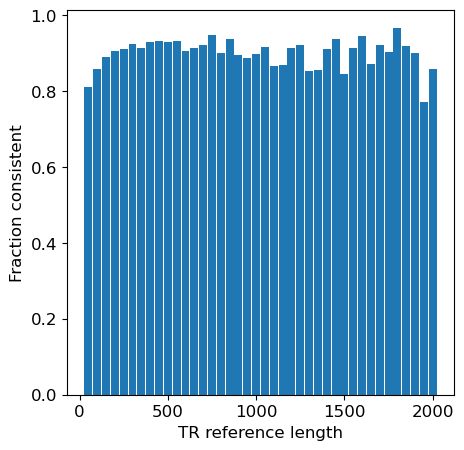

In [30]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(5, 5))

xs = list(range(50, 2001, 50))
ys = [binned_rates[x] for x in xs]

ax.bar(xs, ys, width=45)
ax.set_xlabel("TR reference length")
ax.set_ylabel("Fraction consistent");